# Give Me Some Credit — exploratory analysis

Goal: understand the data before modelling, and justify each rule of `CreditCleaner`.

In [1]:
import matplotlib.pyplot as plt
from credit_scoring import config
from credit_scoring.data import load_dataset

X, y = load_dataset()
X.describe().T

,count,mean,std,min,25%,50%,75%,max
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0
NumberOfDependents,146076.0,0.757222,1.115086,0.0,0.000000,0.000000,1.000000,20.0


## Class imbalance

In [2]:
y.value_counts(normalize=True)

FinancialDistressNextTwoYears
0    0.93316
1    0.06684
Name: proportion, dtype: float64

## Missing values

In [3]:
X.isna().mean().sort_values(ascending=False)

MonthlyIncome                           0.198207
NumberOfDependents                      0.026160
RevolvingUtilizationOfUnsecuredLines    0.000000
age                                     0.000000
NumberOfTime30-59DaysPastDueNotWorse    0.000000
DebtRatio                               0.000000
NumberOfOpenCreditLinesAndLoans         0.000000
NumberOfTimes90DaysLate                 0.000000
NumberRealEstateLoansOrLines            0.000000
NumberOfTime60-89DaysPastDueNotWorse    0.000000
dtype: float64

## Anomalies: implausible ages and special late-payment codes

In [4]:
print('ages < 18:', int((X['age'] < 18).sum()))
X[config.LATE_COLUMNS].isin([96, 98]).sum()

ages < 18: 1


NumberOfTime30-59DaysPastDueNotWorse    269
NumberOfTime60-89DaysPastDueNotWorse    269
NumberOfTimes90DaysLate                 269
dtype: int64

## Revolving utilisation by outcome (clipped at 2)

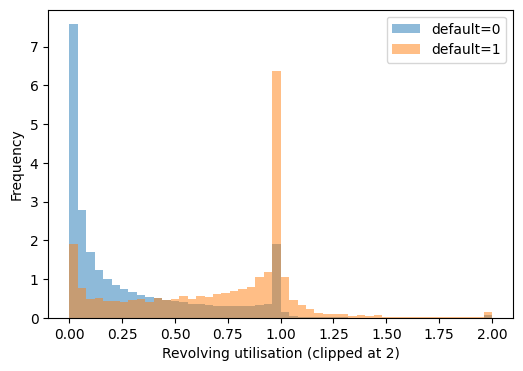

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
for label, grp in X.assign(default=y).groupby('default'):
    grp['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2).plot.hist(bins=50, alpha=0.5, density=True, ax=ax, label=f'default={label}')
ax.legend(); ax.set_xlabel('Revolving utilisation (clipped at 2)');

## Conclusions

- **~20 % of `MonthlyIncome` missing** → median imputation (fitted on train) + `MonthlyIncome_missing` flag.
- **`NumberOfDependents` missing** → 0 + flag.
- **Ages below 18** (an age of 0 exists) → replaced by the train median adult age.
- **Late-payment counts of 96/98** are codes, not counts → flagged (`late_special_code`) and zeroed.
- **Strong imbalance (~6.7 % defaults)** → `scale_pos_weight` in XGBoost, AUC/Gini/KS rather than accuracy.
- Revolving utilisation separates the classes clearly and has extreme outliers → tree models handle it without scaling.